## Single-Category Sales Forecasting Experiments

The objective is to analyze the behavior of all product categories, select representative categories, and train separate forecasting models for individual categories.

### Step 1:  Load cleaned daily category sales

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

daily = pd.read_csv(r"C:\Users\user\internship\daily_category_sales_clean.csv")
daily["Date"] = pd.to_datetime(daily["Date"])

daily.head(10)

,Date,Category,Quantity,Revenue,Orders
0,2010-12-01,"Bag Charms, Key Rings & Phone Charms",1,1.66,1
1,2010-12-01,"Bags, Purses & Backpacks",683,1338.68,26
2,2010-12-01,"Baskets, Hampers & Wicker",83,336.66,14
3,2010-12-01,Cake Cases & Baking Accessories,879,866.83,18
4,2010-12-01,Cake Stands,160,1720.27,19
5,2010-12-01,"Candles, Incense & Matches",1226,1383.02,35
6,2010-12-01,Children's Toys & Playsets,387,906.52,23
7,2010-12-01,Christmas Decorations,1571,1597.25,25
8,2010-12-01,Clocks & Timepieces,200,874.40,10
9,2010-12-01,"Clothing, Accessories & Beauty",83,234.38,13


### Interpretation

The dataset contains one row for each combination of **Date** and **Category**.  
For each category on each day, the table gives:

- `Quantity`: total quantity sold for that category on that date;
- `Revenue`: total revenue generated by that category on that date;
- `Orders`: number of distinct orders/invoices for that category on that date.

The `Date` column was converted to a datetime format, which is necessary for time series analysis, chronological splitting, and forecasting.

The first rows show sales for different product categories on `2010-12-01`.  
For example, on this date, the category **Christmas Decorations** had a high quantity sold, while **Bag Charms, Key Rings & Phone Charms** had a very low quantity sold.


### Step 2: Overview of All Categories

Before selecting the five categories for single-category forecasting, I first analyze all available categories.

The goal is to understand:
- which categories have the highest sales volume;
- which categories are active frequently;
- which categories may be too sparse or irregular for modeling.

In [15]:
print("Dataset shape:", daily.shape)
print("Date range:", daily["Date"].min(), "to", daily["Date"].max())
print("Number of categories:", daily["Category"].nunique())

daily.info()

Dataset shape: (20570, 5)
Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00
Number of categories: 55
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20570 entries, 0 to 20569
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      20570 non-null  datetime64[ns]
 1   Category  20570 non-null  object        
 2   Quantity  20570 non-null  int64         
 3   Revenue   20570 non-null  float64       
 4   Orders    20570 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 803.6+ KB


In [18]:
# Number of daily observations per category

category_counts = (
    daily["Category"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["Category", "Number of Observations"]

category_counts.head(10)

,Category,Number of Observations
0,"Bag Charms, Key Rings & Phone Charms",374
1,"Paper Napkins, Doilies & Bunting",374
2,Jumbo Bags & Shoppers,374
3,Kitchen Storage & Containers,374
4,Kitchen Utensils & Tools,374
5,Lamps & Lampshades,374
6,Lanterns,374
7,Lunch Boxes & Snack Bags,374
8,Memo Boards & Blackboards,374
9,Metal Signs & Plaques,374


### Interpretation

Each category has 374 observations because the dataset is structured as a complete daily panel: one row for each category and each date.
Therefore, the number of observations alone does not help identify important categories, since all categories appear across the same date range.
To select meaningful categories for separate forecasting models, we need to analyze additional indicators such as total quantity sold, number of active selling days, zero-sales days, active ratio, revenue, and variability.

In [21]:
category_summary = (
    daily
    .groupby("Category")
    .agg(
        total_quantity=("Quantity", "sum"),
        mean_daily_quantity=("Quantity", "mean"),
        std_daily_quantity=("Quantity", "std"),
        active_days=("Quantity", lambda x: (x > 0).sum()),
        zero_days=("Quantity", lambda x: (x == 0).sum()),
        total_days=("Quantity", "count"),
        total_revenue=("Revenue", "sum"),
        total_orders=("Orders", "sum")
    )
    .reset_index()
)

category_summary["active_ratio"] = (
    category_summary["active_days"] / category_summary["total_days"]
)

category_summary = category_summary.sort_values(
    "total_quantity",
    ascending=False
)

category_summary.head(15)

,Category,total_quantity,mean_daily_quantity,std_daily_quantity,active_days,zero_days,total_days,total_revenue,total_orders,active_ratio
39,Miscellaneous,552785,1478.034759,1289.080149,305,69,374,993014.70,12291,0.815508
3,Cake Cases & Baking Accessories,278390,744.358289,830.679463,305,69,374,368329.51,7109,0.815508
49,Tealight Holders & Sets,267417,715.018717,648.796995,305,69,374,423925.13,6888,0.815508
30,Jumbo Bags & Shoppers,263509,704.569519,885.471698,305,69,374,541280.32,5565,0.815508
35,Lunch Boxes & Snack Bags,257971,689.762032,737.377023,305,69,374,437533.27,6066,0.815508
11,Colouring & Art Supplies,252008,673.818182,694.521406,305,69,374,168317.09,4564,0.815508
1,"Bags, Purses & Backpacks",247162,660.860963,560.918580,305,69,374,374822.22,6799,0.815508
31,Kitchen Storage & Containers,238868,638.684492,3852.778747,305,69,374,312510.65,5755,0.815508
21,"Gift Wrap, Tape & Ribbons",238756,638.385027,638.306272,305,69,374,185482.21,4891,0.815508
40,"Mugs, Cups & Glasses",228954,612.176471,722.699501,305,69,374,329737.32,7088,0.815508


### Step 3: Visualization of Category Importance

After creating the category summary table, I visualize all categories to better understand their behavior.

The objective is to identify categories that are important, active, and suitable for separate forecasting models.

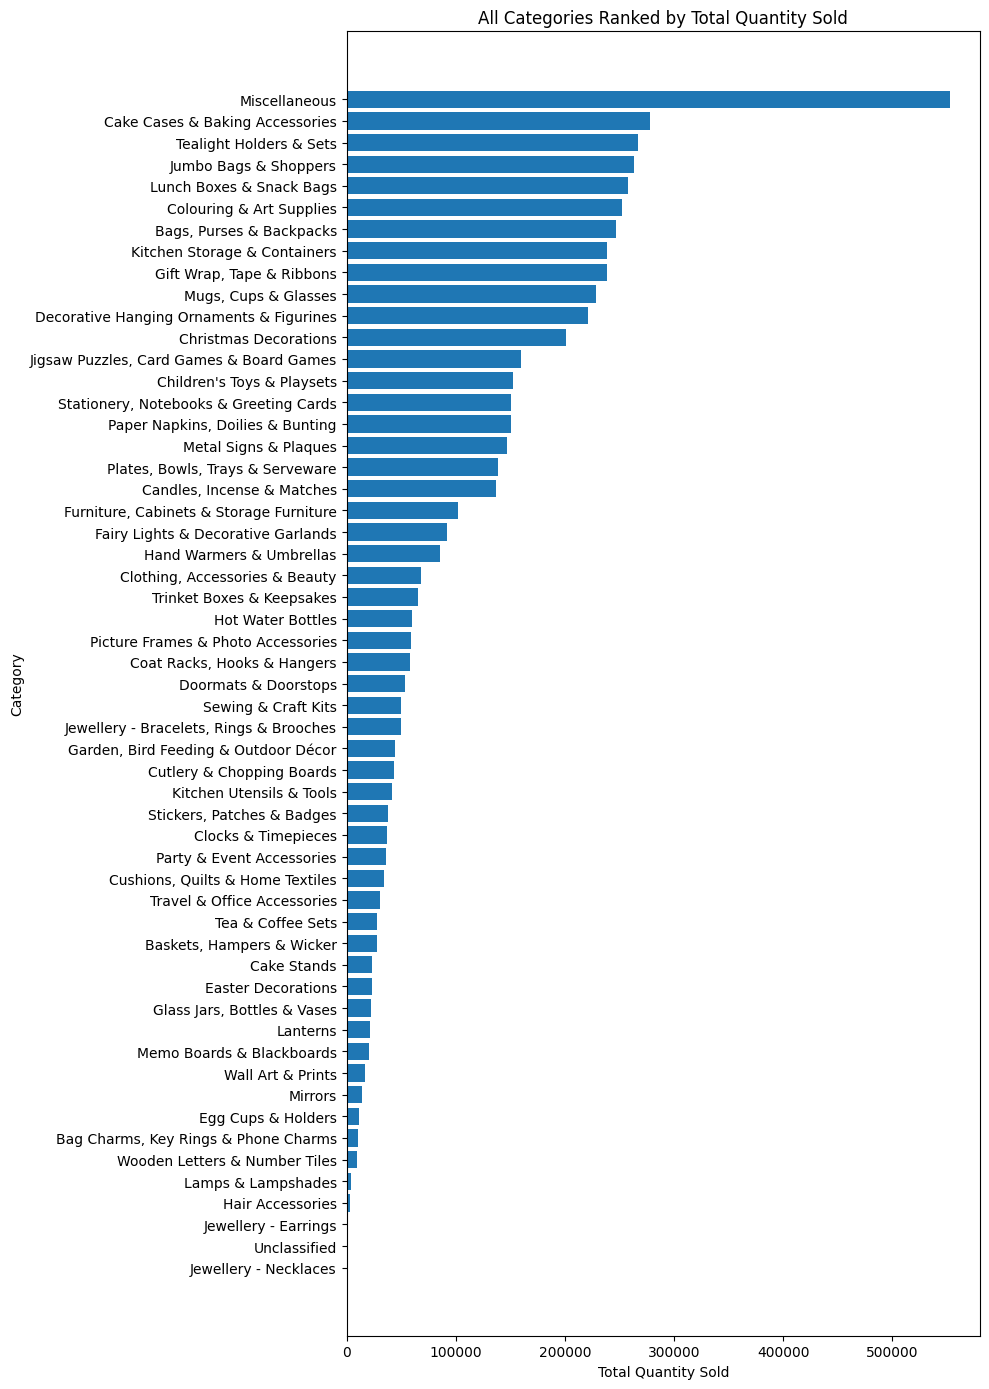

In [24]:
plt.figure(figsize=(10,14))

plt.barh(
    category_summary["Category"],
    category_summary["total_quantity"]
)

plt.gca().invert_yaxis()
plt.title("All Categories Ranked by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Interpretation

The first plot shows that **Miscellaneous** strongly dominates the dataset, with a much higher total quantity than the other categories.

However, this category is a catch-all group of heterogeneous products, so it may not represent a coherent demand pattern.

For this reason, I exclude **Miscellaneous** from the following category selection analysis and focus on more interpretable product categories.

In [27]:
daily = daily[daily["Category"]!="Miscellaneous"]
category_summary = category_summary[category_summary["Category"] != "Miscellaneous"]

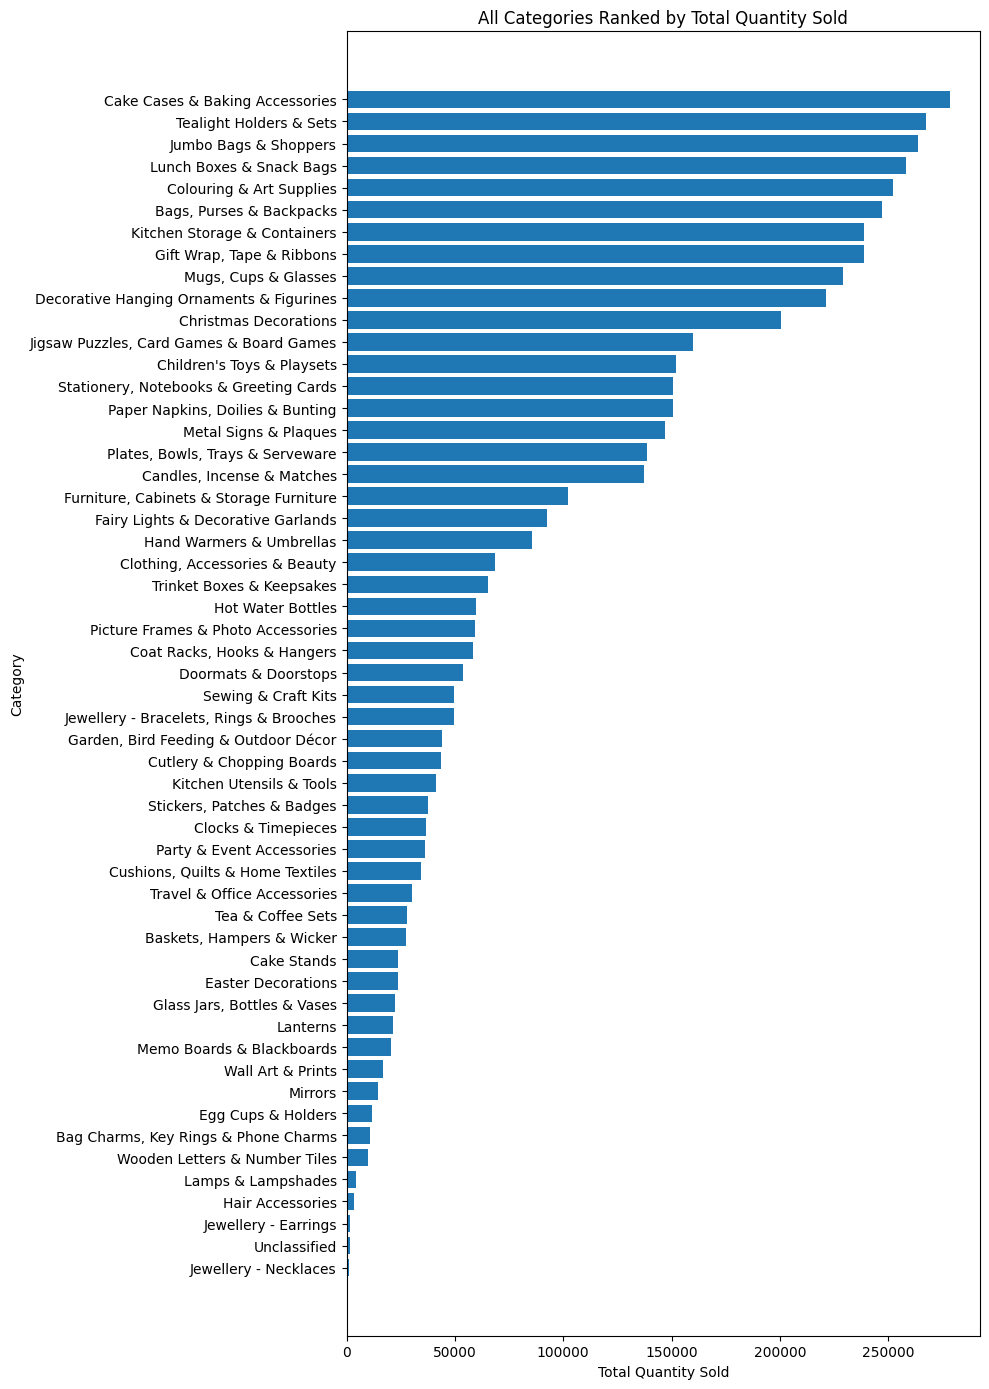

In [29]:
plt.figure(figsize=(10,14))

plt.barh(
    category_summary["Category"],
    category_summary["total_quantity"]
)

plt.gca().invert_yaxis()
plt.title("All Categories Ranked by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

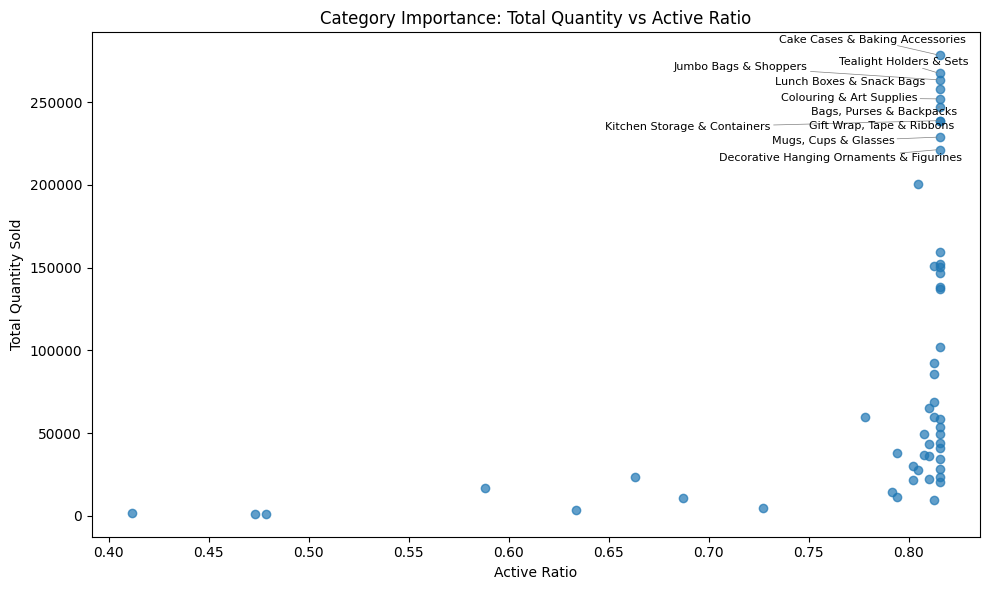

In [232]:

from adjustText import adjust_text

plt.figure(figsize=(10, 6))
plt.scatter(
    category_summary["active_ratio"],
    category_summary["total_quantity"],
    alpha=0.7
)

texts = []
for _, row in category_summary.head(10).iterrows():
    texts.append(plt.text(
        row["active_ratio"],
        row["total_quantity"],
        row["Category"],
        fontsize=8
    ))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.title("Category Importance: Total Quantity vs Active Ratio")
plt.xlabel("Active Ratio")
plt.ylabel("Total Quantity Sold")
plt.tight_layout()
plt.show()

The scatter plot confirms that most high-volume categories cluster 
around an active ratio of 0.81 — meaning they sell on approximately 
81% of all days. These are the most suitable candidates for 
single-category forecasting models.

Categories in the bottom-left corner (active ratio < 0.65) are 
sparse and intermittent — standard regression models are less 
appropriate for these and they will be excluded from single-category 
modeling.

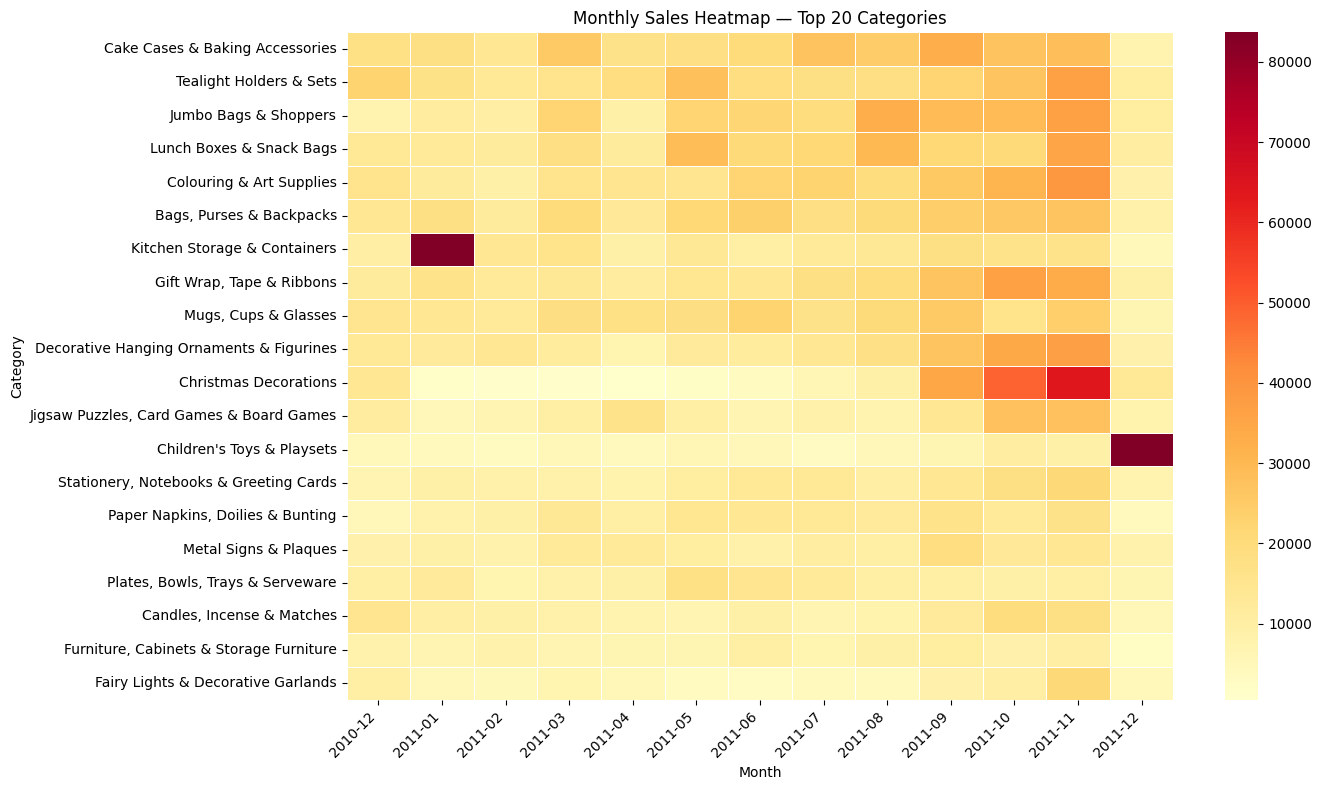

In [34]:
import seaborn as sns
top20 = category_summary.head(20)["Category"].tolist()

monthly_data = daily[daily["Category"].isin(top20)].copy()
monthly_data["Month"] = monthly_data["Date"].dt.to_period("M").dt.to_timestamp()

monthly_pivot = (
    monthly_data
    .pivot_table(
        index="Month",
        columns="Category",
        values="Quantity",
        aggfunc="sum"
    )
    .fillna(0)
)

# Sort by total quantity
monthly_pivot = monthly_pivot[
    monthly_pivot.sum().sort_values(ascending=False).index
]

plt.figure(figsize=(14, 8))
ax = sns.heatmap(
    monthly_pivot.T,
    cmap="YlOrRd",
    linewidths=0.5
)

ax.set_xticklabels(
    [t.get_text()[:7] for t in ax.get_xticklabels()],
    rotation=45,
    ha="right"
)

plt.title("Monthly Sales Heatmap — Top 20 Categories")
plt.tight_layout()
plt.show()

### Interpretation
The heatmap reveals distinct seasonal behaviors across categories:
- Most top categories show stable demand year-round with a slight 
  increase toward Q4.
- **Christmas Decorations** and **Children's Toys & Playsets** show stronger activity near the end of the year, especially around the Christmas period. This suggests seasonal behavior, although sales may still occur during other months.
- **Kitchen Storage & Containers** shows an isolated spike in January 2011, 
  likely a single large bulk order rather than a seasonal pattern.


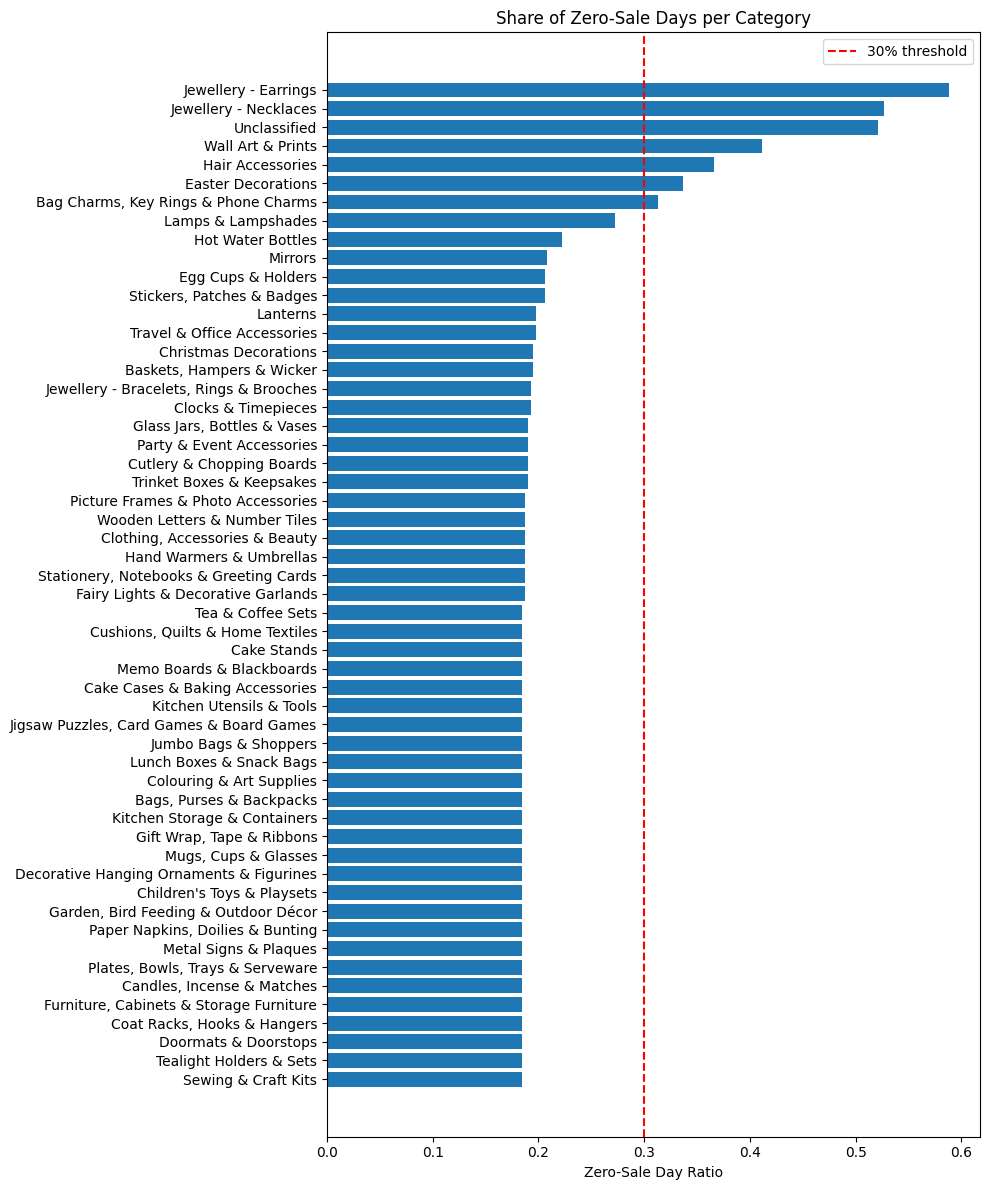

In [36]:
sparsity = category_summary.sort_values("zero_days", ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(sparsity["Category"], sparsity["zero_days"] / sparsity["total_days"])
plt.gca().invert_yaxis()
plt.axvline(x=0.3, color="red", linestyle="--", label="30% threshold")
plt.title("Share of Zero-Sale Days per Category")
plt.xlabel("Zero-Sale Day Ratio")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation
Categories above the 30% threshold have too many zero-sale days 
to be reliably forecast with standard regression models. 
Jewellery categories are the most sparse (~55–60% zero-sales days).  
They are not suitable as standard forecasting candidates, but one Jewellery category is kept as an intermittent-demand stress-test case.

Categories below the threshold show regular daily sales and are 
the most suitable candidates for forecasting.

### Step 4: Category Selection

Based on total volume, active ratio, sparsity, and seasonal behavior, I select five representative categories that cover different forecasting situations:

1. **Tealight Holders & Sets** — high volume and regular demand. Good candidate for standard forecasting models.

2. **Cake Cases & Baking Accessories** — high volume and relatively stable demand. Useful as a strong baseline category.

3. **Jumbo Bags & Shoppers** — high volume but more volatile. This category tests model robustness on noisy demand.

4. **Christmas Decorations** — seasonal category with stronger activity around the end-of-year period. This tests whether models can capture seasonal behavior.

5. **Jewellery - Earrings** — sparse/intermittent category with many zero-sales days. It is included as a stress-test case, not as a standard forecasting candidate.

In [40]:
selected_categories = [
    "Tealight Holders & Sets",
    "Cake Cases & Baking Accessories",
    "Jumbo Bags & Shoppers",
    "Christmas Decorations",
    "Jewellery - Earrings"
]

selected_data = daily[daily["Category"].isin(selected_categories)].copy()
print(f"Selected {len(selected_categories)} categories")
print(f"Rows: {len(selected_data)}")

Selected 5 categories
Rows: 1870


### Step 5: Time Series Visualization of Selected Categories

We plot the daily sales for each selected category to visually inspect 
their behavior before modeling.

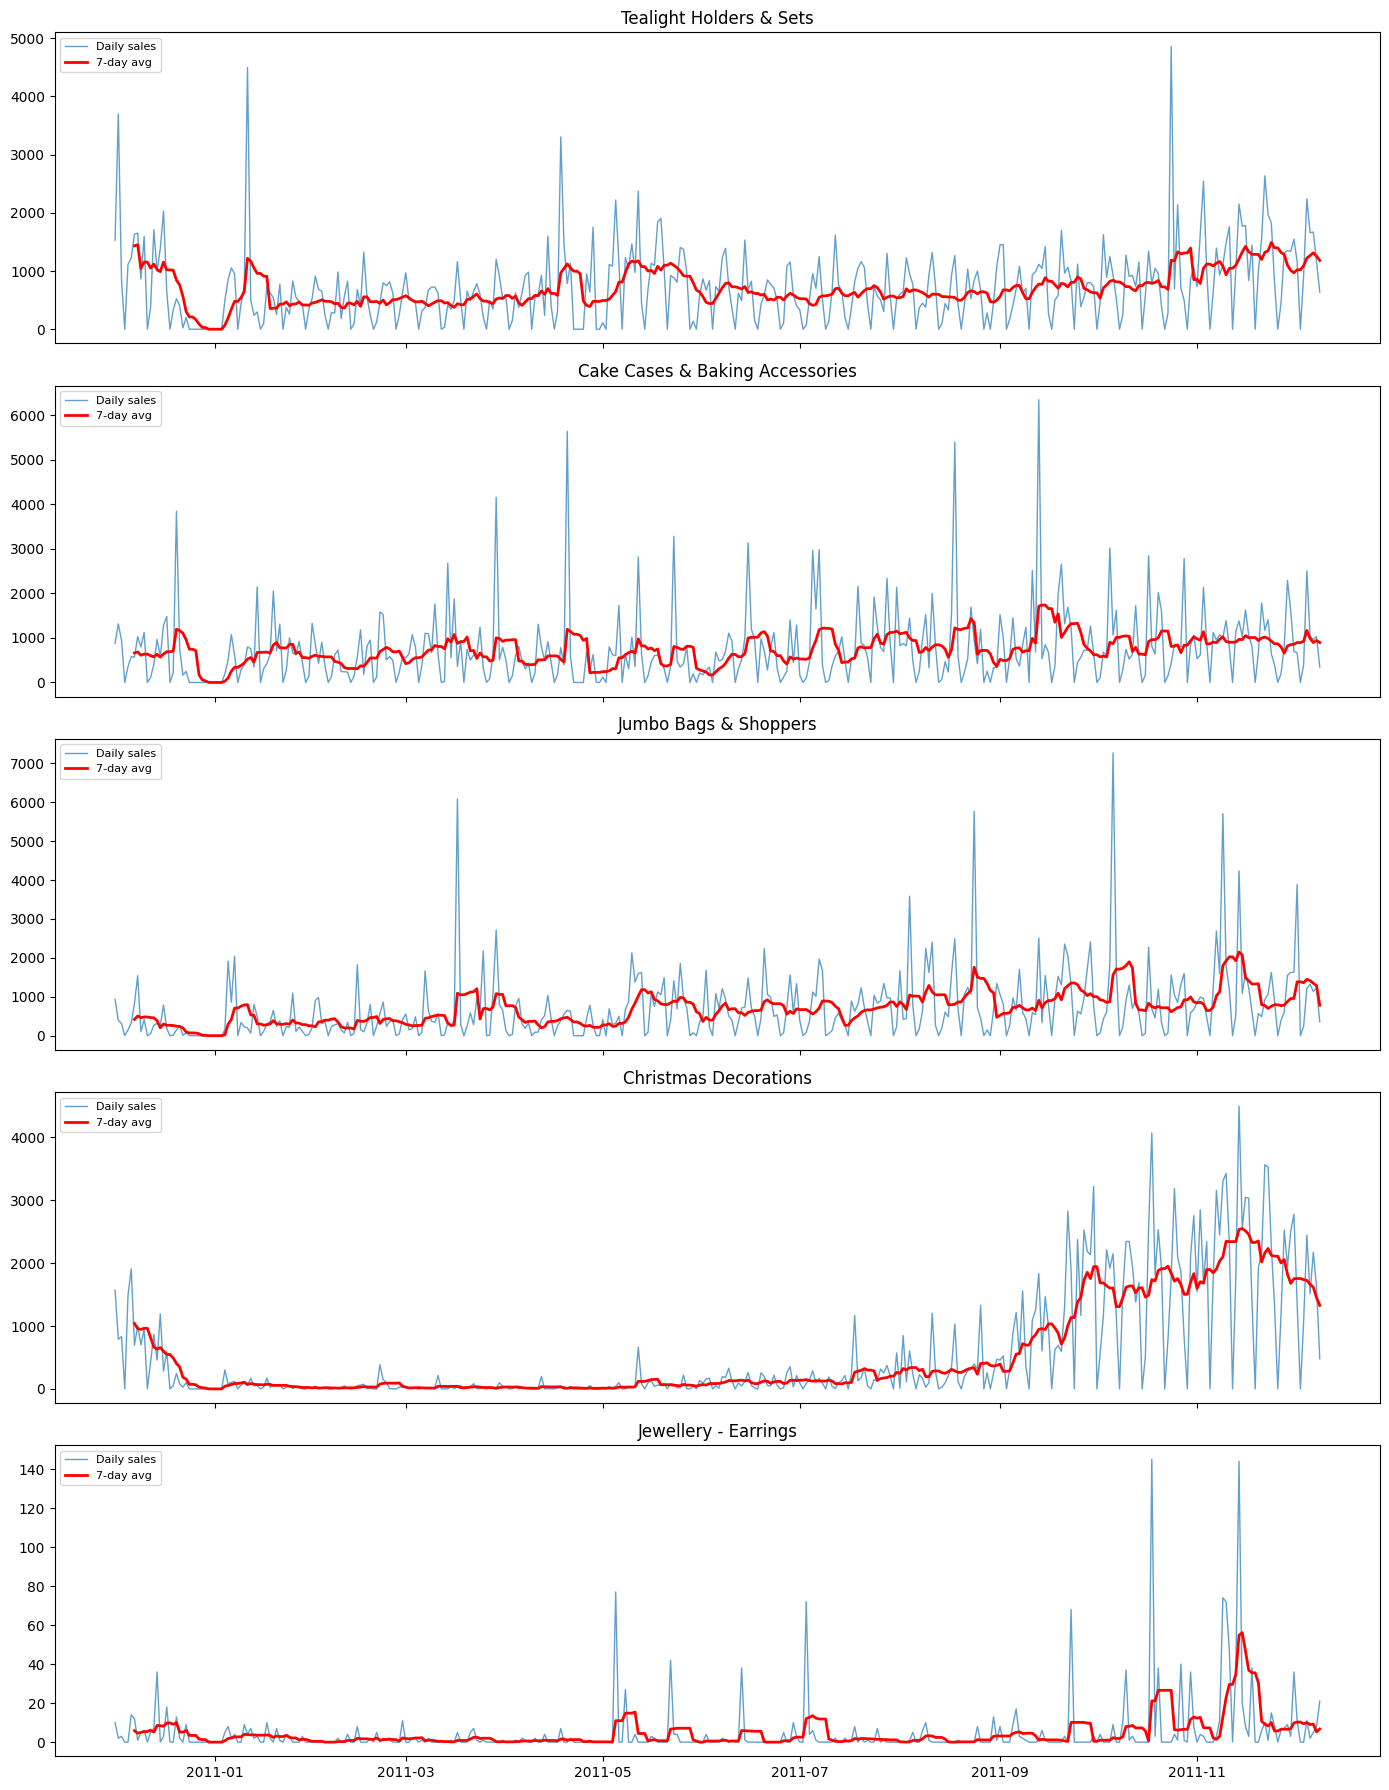

In [42]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

for ax, cat in zip(axes, selected_categories):
    s = selected_data[selected_data["Category"] == cat].set_index("Date")["Quantity"].sort_index()
    ax.plot(s.index, s.values, lw=1, alpha=0.7, label="Daily sales")
    ax.plot(s.index, s.rolling(7).mean(), lw=2, color="red", label="7-day avg")
    ax.set_title(cat)
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation of Selected Category Time Series

The selected categories show different demand behaviors.

**Tealight Holders & Sets** and **Cake Cases & Baking Accessories** have frequent sales with visible fluctuations. These categories are suitable for standard forecasting models such as SARIMA, Random Forest, and XGBoost.

**Jumbo Bags & Shoppers** has high sales volume but appears more volatile, with several sales spikes. This category can be used to test whether the models handle noisy demand patterns.

**Christmas Decorations** shows stronger seasonal behavior, especially near the end of the year. This category may require seasonal features or seasonal time series models.

**Jewellery - Earrings** is much sparser, with many zero-sales days. This category may be difficult for standard regression models and may require a different forecasting approach.

Overall, these five categories provide a useful set of forecasting cases: regular demand, volatile demand, seasonal demand, and intermittent demand.

### Step 6: Explore Time Series Outcomes and Correlations

In this step, I analyze whether the selected category outcomes move together over time.

The objective is to understand whether some categories have similar demand patterns, common seasonal behavior, or correlated sales movements.

This can help decide whether categories should be modeled separately, grouped together, or enriched with cross-category features.

In [201]:
## Create pivot table 
selected_daily = daily[daily["Category"].isin(selected_categories)].copy()

category_pivot = (
    selected_daily
    .pivot_table(
        index="Date",
        columns="Category",
        values="Quantity",
        aggfunc="sum"
    )
    .fillna(0)
)

category_pivot.head()

Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Date,,,,,
2010-12-01,879,1571,10,932,1530
2010-12-02,1314,790,2,393,3697
2010-12-03,946,831,3,309,841
2010-12-04,0,0,0,0,0
2010-12-05,359,1486,0,150,1112


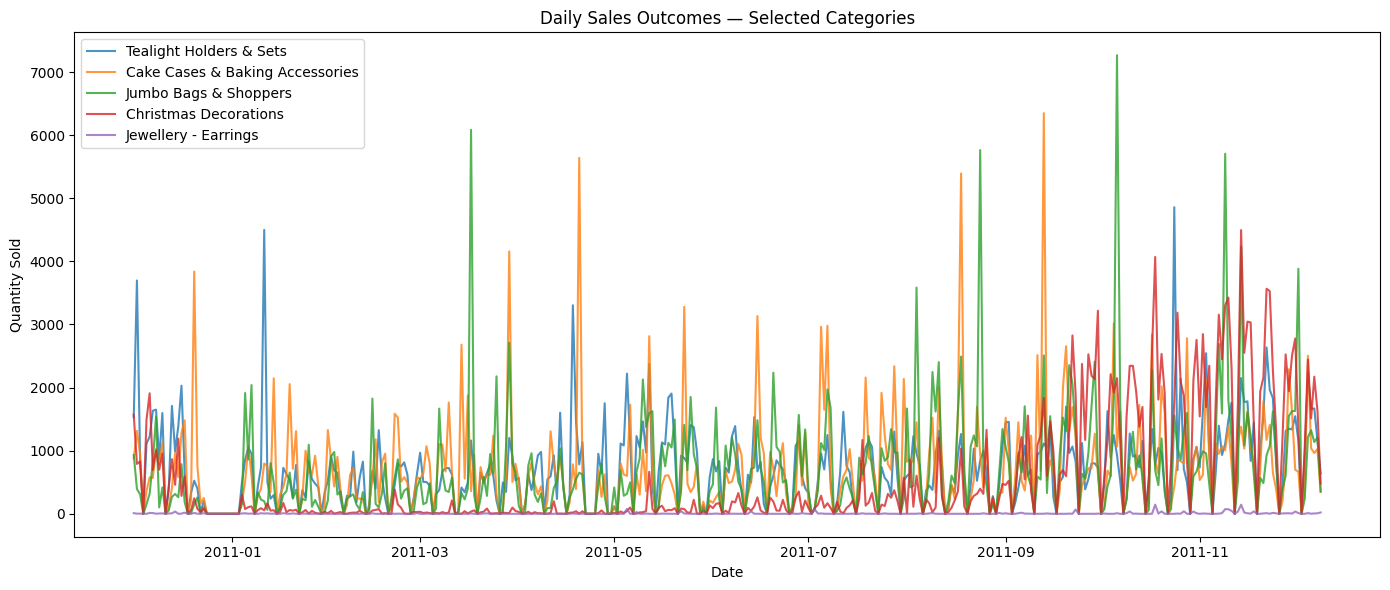

In [203]:
## Plot selected category outcomes together
plt.figure(figsize=(14, 6))

for category in selected_categories:
    plt.plot(
        category_pivot.index,
        category_pivot[category],
        label=category,
        alpha=0.8
    )

plt.title("Daily Sales Outcomes — Selected Categories")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()

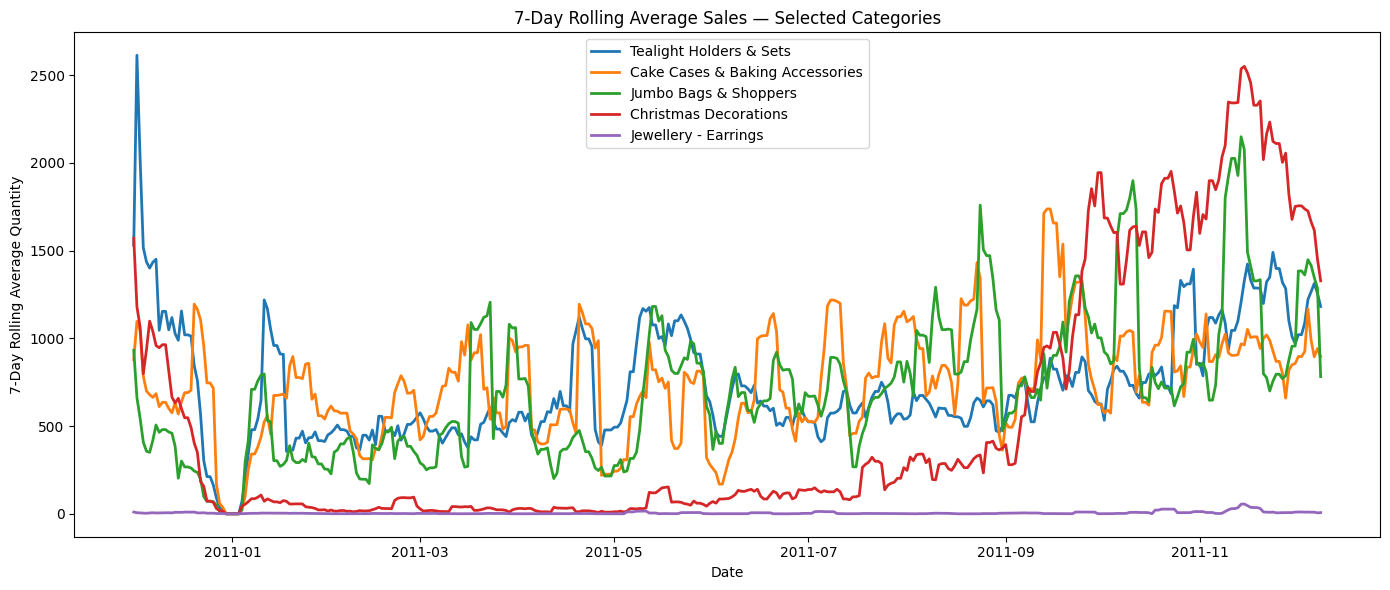

In [207]:
## Plot 7-day rolling average together
rolling_category_pivot = category_pivot.rolling(7, min_periods=1).mean()

plt.figure(figsize=(14, 6))

for category in selected_categories:
    plt.plot(
        rolling_category_pivot.index,
        rolling_category_pivot[category],
        label=category,
        linewidth=2
    )

plt.title("7-Day Rolling Average Sales — Selected Categories")
plt.xlabel("Date")
plt.ylabel("7-Day Rolling Average Quantity")
plt.legend()
plt.tight_layout()
plt.show()

In [209]:
## Correlation Matrix
category_corr = category_pivot.corr()

category_corr

Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Category,,,,,
Cake Cases & Baking Accessories,1.000000,0.288139,0.065189,0.398814,0.372578
Christmas Decorations,0.288139,1.000000,0.454617,0.409419,0.451641
Jewellery - Earrings,0.065189,0.454617,1.000000,0.234004,0.206722
Jumbo Bags & Shoppers,0.398814,0.409419,0.234004,1.000000,0.382019
Tealight Holders & Sets,0.372578,0.451641,0.206722,0.382019,1.000000


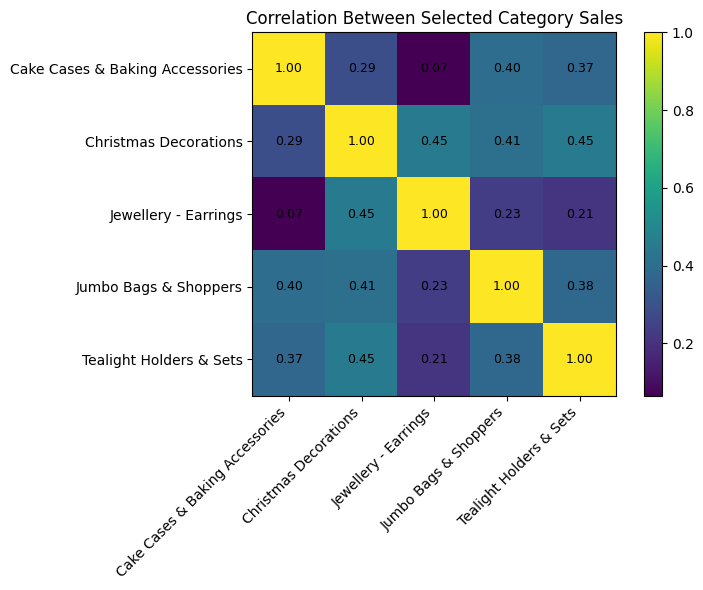

In [211]:
## Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(category_corr.values)

ax.set_xticks(range(len(category_corr.columns)))
ax.set_yticks(range(len(category_corr.index)))

ax.set_xticklabels(category_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(category_corr.index)

for i in range(len(category_corr.index)):
    for j in range(len(category_corr.columns)):
        ax.text(
            j,
            i,
            f"{category_corr.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.colorbar(im, ax=ax)
ax.set_title("Correlation Between Selected Category Sales")
plt.tight_layout()
plt.show()

### Interpretation

The selected categories show different sales behaviors over time.

The daily time series plot shows that some categories have regular demand, while others are more volatile or sparse. The 7-day rolling average helps smooth short-term fluctuations and makes the global sales patterns easier to compare.

The correlation matrix shows that the selected categories are not strongly correlated overall. Most correlations are low to moderate, which means that the categories do not always increase or decrease together.

This supports the decision to build separate forecasting models for each category instead of using only one global model.

Some moderate correlations may indicate shared demand periods, common seasonality, or similar customer behavior. However, the correlations are not strong enough to assume that all categories follow the same sales pattern.

### Step 7: Prepare Single-Category Forecasting Datasets
For each selected category, I create a separate forecasting dataset.

The objective is to drop all other categories and keep only one category at a time.  
This allows each model to learn the specific behavior of one category instead of learning a global pattern across all categories.

For each category, I create:

- the forecasting target `target_X7_Y7`;
- lag features such as `lag_1`, `lag_7`, `lag_14`, and `lag_28`;
- rolling-window features such as `rolling_mean_7` and `rolling_sum_7`;
- calendar features such as day of week and month.

In [60]:
X = 7  # prediction horizon: next 7 days
Y = 7  # prediction made 7 days in advance

target_col = f"target_X{X}_Y{Y}"

target_col

'target_X7_Y7'

In [62]:
def prepare_single_category_dataset(daily_data, category_name, X=7, Y=7):
    """
    Prepare a forecasting dataset for one category only.
    
    For each date, the target is the total quantity sold over the next X days,
    starting Y days after the current date.
    """
    
    # Keep only one category
    category_data = (
        daily_data[daily_data["Category"] == category_name]
        .sort_values("Date")
        .copy()
    )
    
    # Keep useful columns
    category_data = category_data[
        ["Date", "Category", "Quantity", "Revenue", "Orders"]
    ].copy()
    
    # Make sure dates are ordered
    category_data["Date"] = pd.to_datetime(category_data["Date"])
    category_data = category_data.sort_values("Date").reset_index(drop=True)
    
    # Create target
    quantities = category_data["Quantity"].values
    targets = []
    
    for i in range(len(category_data)):
        start = i + Y
        end = i + Y + X
        
        if end <= len(category_data):
            targets.append(quantities[start:end].sum())
        else:
            targets.append(np.nan)
    
    category_data[f"target_X{X}_Y{Y}"] = targets
    
    # Lag features
    category_data["lag_1"] = category_data["Quantity"].shift(1)
    category_data["lag_7"] = category_data["Quantity"].shift(7)
    category_data["lag_14"] = category_data["Quantity"].shift(14)
    category_data["lag_28"] = category_data["Quantity"].shift(28)
    
    # Rolling-window features
    category_data["rolling_mean_7"] = category_data["Quantity"].shift(1).rolling(7).mean()
    category_data["rolling_mean_14"] = category_data["Quantity"].shift(1).rolling(14).mean()
    category_data["rolling_sum_7"] = category_data["Quantity"].shift(1).rolling(7).sum()
    category_data["rolling_sum_14"] = category_data["Quantity"].shift(1).rolling(14).sum()
    
    # Calendar features
    category_data["day_of_week"] = category_data["Date"].dt.dayofweek
    category_data["month"] = category_data["Date"].dt.month
    
    # Drop rows where target or lag features are not available
    category_data = category_data.dropna().reset_index(drop=True)
    
    return category_data

In [64]:
single_category_datasets = {}

for category in selected_categories:
    single_category_datasets[category] = prepare_single_category_dataset(
        daily_data=daily,
        category_name=category,
        X=X,
        Y=Y
    )

single_category_datasets.keys()

dict_keys(['Tealight Holders & Sets', 'Cake Cases & Baking Accessories', 'Jumbo Bags & Shoppers', 'Christmas Decorations', 'Jewellery - Earrings'])

In [72]:
example_category = selected_categories[0]

single_category_datasets[example_category].head()

,Date,Category,Quantity,Revenue,Orders,target_X7_Y7,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_sum_7,rolling_sum_14,day_of_week,month
0,2010-12-29,Tealight Holders & Sets,0,0.0,0,8534.0,0.0,24.0,1387.0,1530.0,32.142857,396.000000,225.0,5544.0,2,12
1,2010-12-30,Tealight Holders & Sets,0,0.0,0,8182.0,0.0,201.0,2030.0,3697.0,28.714286,296.928571,201.0,4157.0,3,12
2,2010-12-31,Tealight Holders & Sets,0,0.0,0,7370.0,0.0,0.0,645.0,841.0,0.000000,151.928571,0.0,2127.0,4,12
3,2011-01-01,Tealight Holders & Sets,0,0.0,0,6714.0,0.0,0.0,0.0,0.0,0.000000,105.857143,0.0,1482.0,5,1
4,2011-01-02,Tealight Holders & Sets,0,0.0,0,6714.0,0.0,0.0,331.0,1112.0,0.000000,105.857143,0.0,1482.0,6,1


In [68]:
for category, data in single_category_datasets.items():
    print(category, ":", data.shape)

Tealight Holders & Sets : (333, 16)
Cake Cases & Baking Accessories : (333, 16)
Jumbo Bags & Shoppers : (333, 16)
Christmas Decorations : (333, 16)
Jewellery - Earrings : (333, 16)


### Step 8: Train / Validation / Test Split

For each single-category dataset, I use a chronological train / validation / test split.

- The training set is used to fit the models.  
- The validation set is used to compare models and tune modeling choices.  
- The test set is kept for final evaluation.

A chronological split is necessary because this is a forecasting problem. The model should learn from past observations and be evaluated on future observations.

In [76]:
def time_train_val_test_split(data, train_size=0.6, val_size=0.2):
    data = data.sort_values("Date").reset_index(drop=True)
    
    n = len(data)
    
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    
    train_df = data.iloc[:train_end].copy()
    val_df = data.iloc[train_end:val_end].copy()
    test_df = data.iloc[val_end:].copy()
    
    return train_df, val_df, test_df

In [78]:
single_category_splits = {}

for category, data in single_category_datasets.items():
    train_df, val_df, test_df = time_train_val_test_split(data)
    
    single_category_splits[category] = {
        "train": train_df,
        "validation": val_df,
        "test": test_df
    }
    
    print(category)
    print("Train:", train_df["Date"].min(), "to", train_df["Date"].max(), train_df.shape)
    print("Validation:", val_df["Date"].min(), "to", val_df["Date"].max(), val_df.shape)
    print("Test:", test_df["Date"].min(), "to", test_df["Date"].max(), test_df.shape)
    print("-" * 80)

Tealight Holders & Sets
Train: 2010-12-29 00:00:00 to 2011-07-15 00:00:00 (199, 16)
Validation: 2011-07-16 00:00:00 to 2011-09-20 00:00:00 (67, 16)
Test: 2011-09-21 00:00:00 to 2011-11-26 00:00:00 (67, 16)
--------------------------------------------------------------------------------
Cake Cases & Baking Accessories
Train: 2010-12-29 00:00:00 to 2011-07-15 00:00:00 (199, 16)
Validation: 2011-07-16 00:00:00 to 2011-09-20 00:00:00 (67, 16)
Test: 2011-09-21 00:00:00 to 2011-11-26 00:00:00 (67, 16)
--------------------------------------------------------------------------------
Jumbo Bags & Shoppers
Train: 2010-12-29 00:00:00 to 2011-07-15 00:00:00 (199, 16)
Validation: 2011-07-16 00:00:00 to 2011-09-20 00:00:00 (67, 16)
Test: 2011-09-21 00:00:00 to 2011-11-26 00:00:00 (67, 16)
--------------------------------------------------------------------------------
Christmas Decorations
Train: 2010-12-29 00:00:00 to 2011-07-15 00:00:00 (199, 16)
Validation: 2011-07-16 00:00:00 to 2011-09-20 00:00

### Step 9: Train Separate Models for Each Category

In this step, I train separate forecasting models for each selected category.

For each category, the models are trained only on that category's data.  
This allows each model to learn the specific demand behavior of one category.

The first models tested are:

- Moving Average baseline;
- Linear Regression;
- Random Forest Regressor.
- XGBoost Regressor.

The models are compared first on the validation set, then evaluated on the test set.

In [149]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

In [151]:
def evaluate_forecast(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    if np.sum(np.abs(y_true)) == 0:
        wape = np.nan
    else:
        wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    
    bias = np.mean(y_pred - y_true)
    
    return mae, rmse, wape, bias

In [153]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_sum_7",
    "rolling_sum_14",
    "day_of_week",
    "month"
]

target_col = "target_X7_Y7"

In [155]:
all_results = []

for category, splits in single_category_splits.items():
    train_df = splits["train"]
    val_df = splits["validation"]
    test_df = splits["test"]
    
    X_train = train_df[features]
    y_train = train_df[target_col]
    
    X_val = val_df[features]
    y_val = val_df[target_col]
    
    X_test = test_df[features]
    y_test = test_df[target_col]
    
    models = {
        "Moving Average 7 days": None,
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
        "XGBoost": XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            n_jobs=-1
        )
    }
    
    for model_name, model in models.items():
        
        if model_name == "Moving Average 7 days":
            val_pred = val_df["rolling_sum_7"].values
            test_pred = test_df["rolling_sum_7"].values
        
        else:
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)
            test_pred = model.predict(X_test)
        
        val_mae, val_rmse, val_wape, val_bias = evaluate_forecast(y_val, val_pred)
        test_mae, test_rmse, test_wape, test_bias = evaluate_forecast(y_test, test_pred)
        
        all_results.append({
            "Category": category,
            "Model": model_name,
            "Validation MAE": val_mae,
            "Validation RMSE": val_rmse,
            "Validation WAPE": val_wape,
            "Validation Bias": val_bias,
            "Test MAE": test_mae,
            "Test RMSE": test_rmse,
            "Test WAPE": test_wape,
            "Test Bias": test_bias
        })

results_single_category = pd.DataFrame(all_results)

results_single_category.sort_values(["Category", "Validation MAE"])

,Category,Model,Validation MAE,Validation RMSE,Validation WAPE,Validation Bias,Test MAE,Test RMSE,Test WAPE,Test Bias
6,Cake Cases & Baking Accessories,Random Forest,2141.401567,2793.676346,0.321242,-1009.662612,990.012761,1296.297820,0.154406,-499.610373
5,Cake Cases & Baking Accessories,Linear Regression,2182.494444,2913.821943,0.327407,-1745.130571,1432.538354,1617.094748,0.223425,-1220.614384
7,Cake Cases & Baking Accessories,XGBoost,2277.258337,2972.573599,0.341623,-797.355061,1070.019444,1356.499898,0.166885,-172.526309
4,Cake Cases & Baking Accessories,Moving Average 7 days,3521.865672,4248.071821,0.528333,-251.805970,991.134328,1238.301714,0.154581,78.507463
12,Christmas Decorations,Moving Average 7 days,1868.985075,2716.925111,0.409284,-1800.716418,2681.134328,3277.550933,0.206413,-441.014925
13,Christmas Decorations,Linear Regression,2473.819421,3621.540309,0.541735,-2438.831961,4936.312874,5506.441140,0.380033,-4869.428325
14,Christmas Decorations,Random Forest,3053.074328,4633.965640,0.668584,-3040.876716,11582.395299,11799.598555,0.891696,-11582.395299
15,Christmas Decorations,XGBoost,3147.758479,4837.357097,0.689319,-3075.600477,12079.844436,12294.533281,0.929993,-12079.844436
16,Jewellery - Earrings,Moving Average 7 days,17.208955,22.432985,0.960033,-5.805970,108.791045,142.221973,1.117773,-3.925373
18,Jewellery - Earrings,Random Forest,17.244104,23.430457,0.961994,-0.275448,73.187612,114.755853,0.751966,-68.626269


### Interpretation

The model comparison shows that the best forecasting model depends on the category.

For some categories, the Moving Average baseline performs very well. This means that recent sales history is already a strong predictor of future demand.

For other categories, Linear Regression or Random Forest performs better, which suggests that lag, rolling, and calendar features can add useful predictive information.

However, the validation and test results are not always aligned. A model that performs well on the validation period does not necessarily perform best on the test period. This confirms the importance of keeping a separate test set for final evaluation.

Overall, the results show that category-specific forecasting is useful because each category has its own demand behavior.

### Step 10: Visualize Model Comparison

To better compare the models, I visualize the test MAE for each category and model.

The test MAE is used because it measures the final performance on the most recent unseen period.

In [218]:
pivot_test_mae = results_single_category.pivot(
    index="Category",
    columns="Model",
    values="Test MAE"
)

pivot_test_mae

Model,Linear Regression,Moving Average 7 days,Random Forest,XGBoost
Category,,,,
Cake Cases & Baking Accessories,1432.538354,991.134328,990.012761,1070.019444
Christmas Decorations,4936.312874,2681.134328,11582.395299,12079.844436
Jewellery - Earrings,71.052259,108.791045,73.187612,78.506868
Jumbo Bags & Shoppers,3086.136060,4052.776119,3646.716716,3670.626866
Tealight Holders & Sets,1605.616824,1563.477612,2749.492612,3201.858657


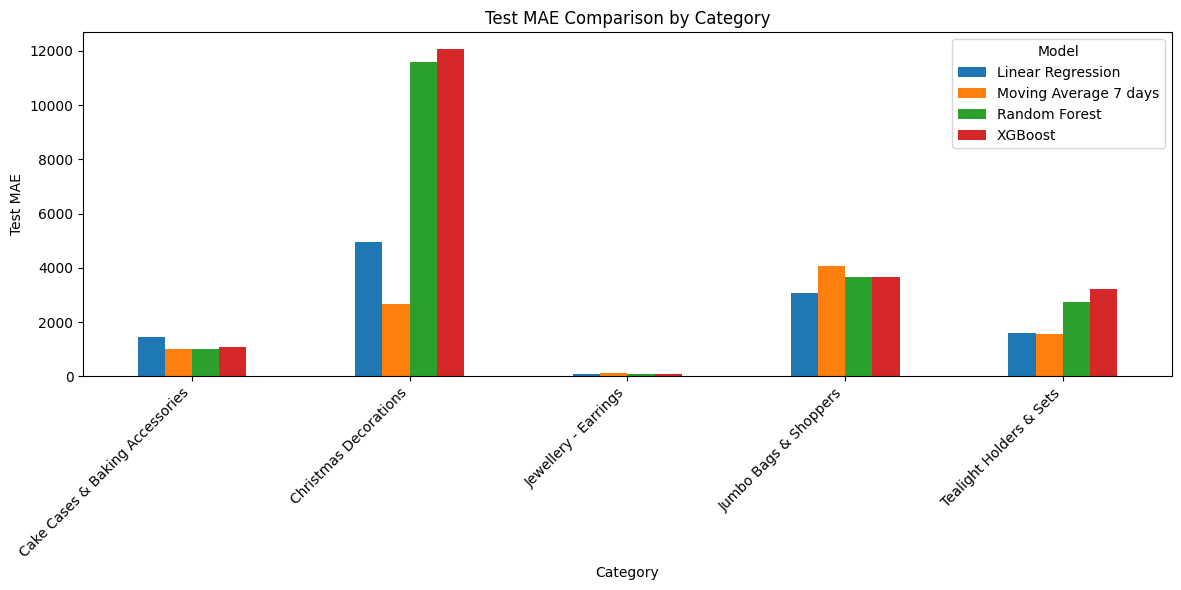

In [229]:
pivot_test_mae.plot(kind="bar", figsize=(12, 6))

plt.title("Test MAE Comparison by Category")
plt.ylabel("Test MAE")
plt.xlabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

The Test MAE comparison plot shows the final forecasting error of each model for each selected category.

The results confirm that model performance depends strongly on the category. No single model is consistently the best for all categories.

For some categories, the Moving Average baseline remains competitive, which means that recent historical sales already contain useful information for predicting future demand.

For other categories, regression-based models such as Linear Regression, Random Forest, or XGBoost may perform better, suggesting that lag, rolling, and calendar features can improve forecasting performance.

The plot also shows that some categories have much larger errors than others. This is expected because categories with higher sales volume, stronger seasonality, or more volatile demand are harder to forecast in absolute quantity terms.

Overall, the comparison supports the use of category-specific forecasting models instead of applying one single model to all product categories.

### Step 11: Best Model per Category

After training separate models for each category, I identify the best model for each category based on validation MAE.

The validation set is used for model selection because the test set should remain the final unseen evaluation period.

In [165]:
best_validation_models = (
    results_single_category
    .sort_values("Validation MAE")
    .groupby("Category")
    .first()
    .reset_index()
)

best_validation_models[
    ["Category", "Model", "Validation MAE", "Validation WAPE", "Test MAE", "Test WAPE", "Test Bias"]
]

,Category,Model,Validation MAE,Validation WAPE,Test MAE,Test WAPE,Test Bias
0,Cake Cases & Baking Accessories,Random Forest,2141.401567,0.321242,990.012761,0.154406,-499.610373
1,Christmas Decorations,Moving Average 7 days,1868.985075,0.409284,2681.134328,0.206413,-441.014925
2,Jewellery - Earrings,Moving Average 7 days,17.208955,0.960033,108.791045,1.117773,-3.925373
3,Jumbo Bags & Shoppers,Linear Regression,1865.257310,0.274288,3086.136060,0.392715,-1846.872767
4,Tealight Holders & Sets,Random Forest,695.363060,0.153108,2749.492612,0.370446,-2749.492612


### Step 12: Explore Generated Feature Usefulness
The generated features may not all be informative.

In this step, I analyze the relationship between the generated features and the forecasting target `target_X7_Y7`.

The objective is to identify which lag, rolling, and calendar features are useful, and which features may be weak or redundant.

In [179]:
feature_target_correlations = []

for category, data in single_category_datasets.items():
    corr_values = (
        data[features + [target_col]]
        .corr()[target_col]
        .drop(target_col)
    )
    
    for feature, corr in corr_values.items():
        feature_target_correlations.append({
            "Category": category,
            "Feature": feature,
            "Correlation with Target": corr
        })

feature_corr_df = pd.DataFrame(feature_target_correlations)

feature_corr_df["Abs Correlation"] = feature_corr_df["Correlation with Target"].abs()

feature_corr_df.head()

,Category,Feature,Correlation with Target,Abs Correlation
0,Tealight Holders & Sets,lag_1,0.238028,0.238028
1,Tealight Holders & Sets,lag_7,0.189602,0.189602
2,Tealight Holders & Sets,lag_14,0.195160,0.195160
3,Tealight Holders & Sets,lag_28,0.121105,0.121105
4,Tealight Holders & Sets,rolling_mean_7,0.430225,0.430225


In [181]:
## strongest features by category
strongest_features = (
    feature_corr_df
    .sort_values(["Category", "Abs Correlation"], ascending=[True, False])
)

strongest_features

,Category,Feature,Correlation with Target,Abs Correlation
19,Cake Cases & Baking Accessories,month,0.431494,0.431494
15,Cake Cases & Baking Accessories,rolling_mean_14,0.235625,0.235625
17,Cake Cases & Baking Accessories,rolling_sum_14,0.235625,0.235625
12,Cake Cases & Baking Accessories,lag_14,0.167387,0.167387
14,Cake Cases & Baking Accessories,rolling_mean_7,0.050361,0.050361
16,Cake Cases & Baking Accessories,rolling_sum_7,0.050361,0.050361
13,Cake Cases & Baking Accessories,lag_28,0.046438,0.046438
11,Cake Cases & Baking Accessories,lag_7,0.035500,0.035500
10,Cake Cases & Baking Accessories,lag_1,0.013504,0.013504
18,Cake Cases & Baking Accessories,day_of_week,-0.001935,0.001935


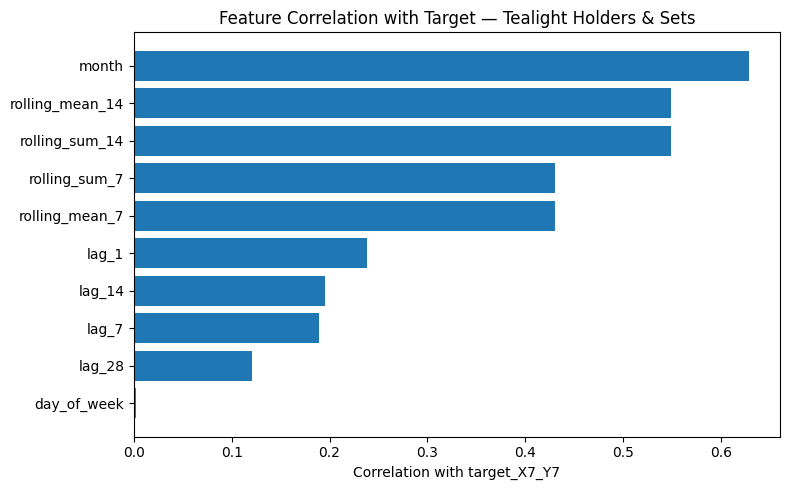

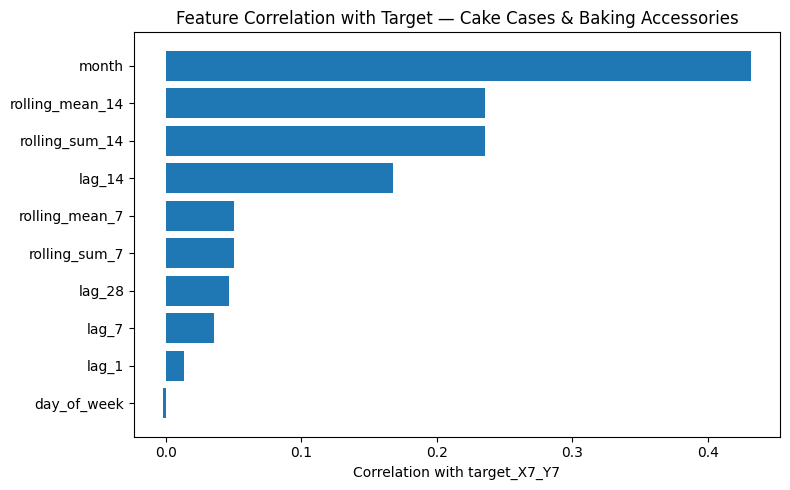

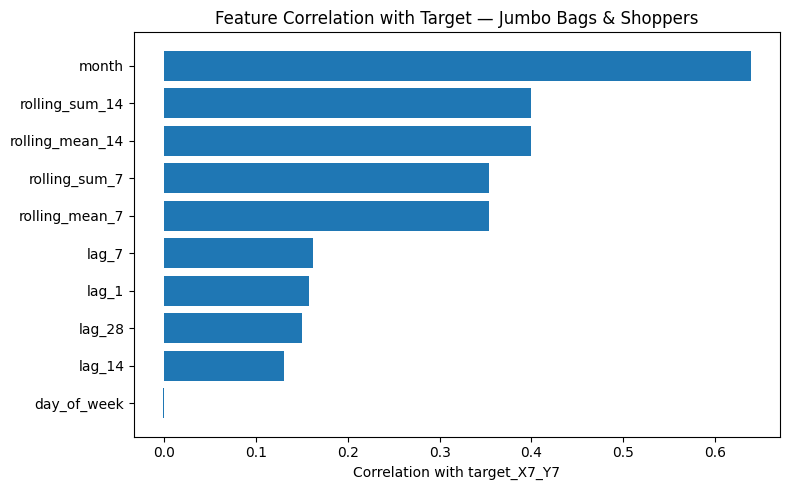

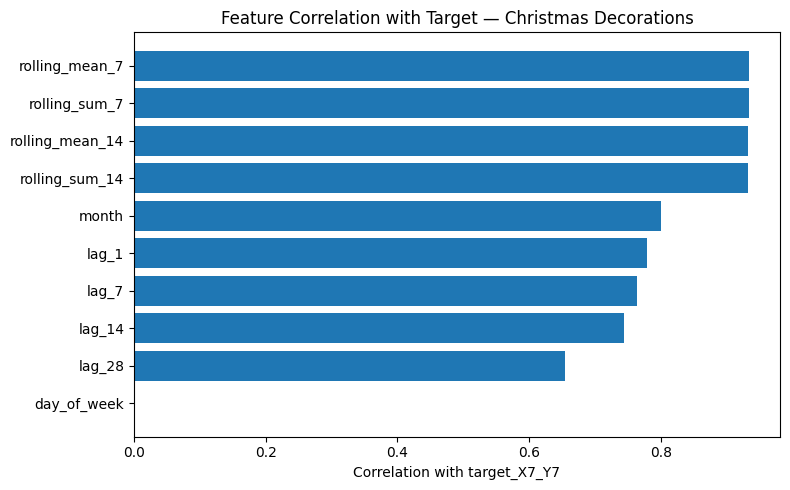

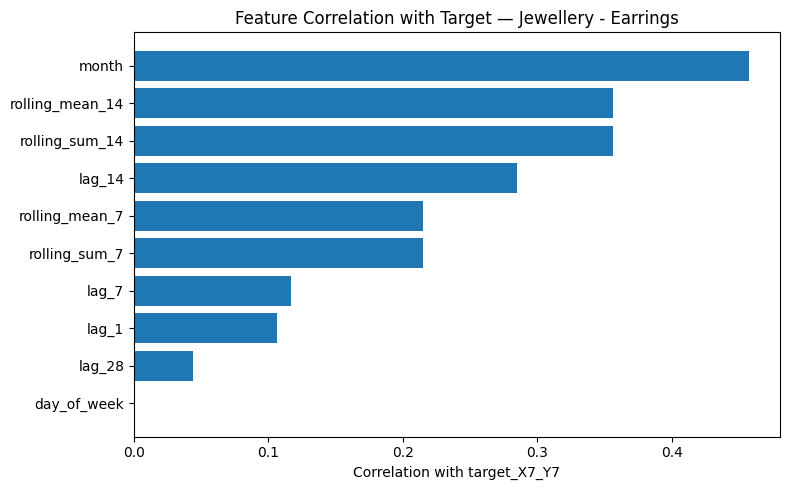

In [183]:
## Plot feature correlation for each category
for category in selected_categories:
    category_feature_corr = (
        feature_corr_df[feature_corr_df["Category"] == category]
        .sort_values("Correlation with Target")
    )
    
    plt.figure(figsize=(8, 5))
    plt.barh(
        category_feature_corr["Feature"],
        category_feature_corr["Correlation with Target"]
    )
    plt.title(f"Feature Correlation with Target — {category}")
    plt.xlabel("Correlation with target_X7_Y7")
    plt.tight_layout()
    plt.show()

### Step 13: Random Forest Feature Importance

Correlation measures linear relationships, but some features may be useful in a nonlinear way.

Therefore, I also use Random Forest feature importance to analyze which features contribute most to prediction.

In [185]:
feature_importance_results = []

for category, splits in single_category_splits.items():
    train_df = splits["train"]
    
    X_train = train_df[features]
    y_train = train_df[target_col]
    
    rf = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    for feature, importance in zip(features, rf.feature_importances_):
        feature_importance_results.append({
            "Category": category,
            "Feature": feature,
            "Importance": importance
        })

feature_importance_df = pd.DataFrame(feature_importance_results)

feature_importance_df.head()

,Category,Feature,Importance
0,Tealight Holders & Sets,lag_1,0.037731
1,Tealight Holders & Sets,lag_7,0.040230
2,Tealight Holders & Sets,lag_14,0.032132
3,Tealight Holders & Sets,lag_28,0.021326
4,Tealight Holders & Sets,rolling_mean_7,0.141000


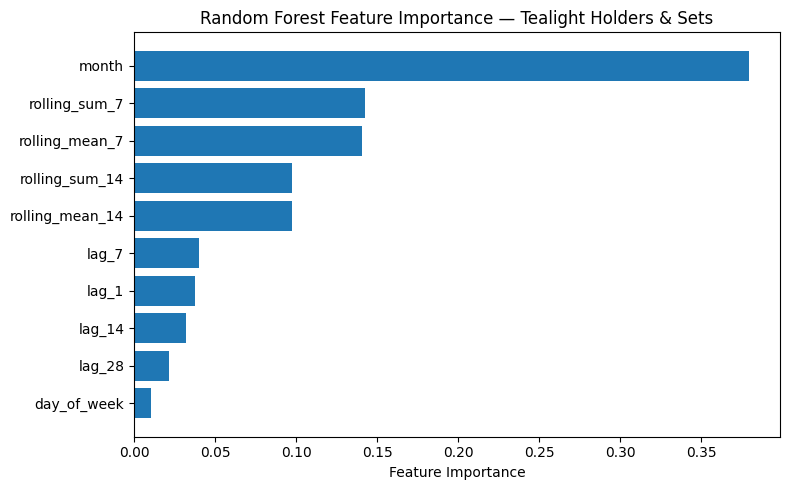

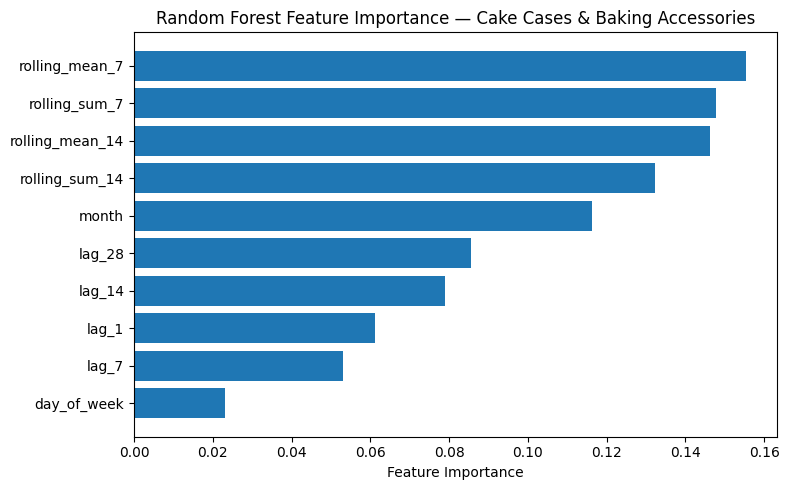

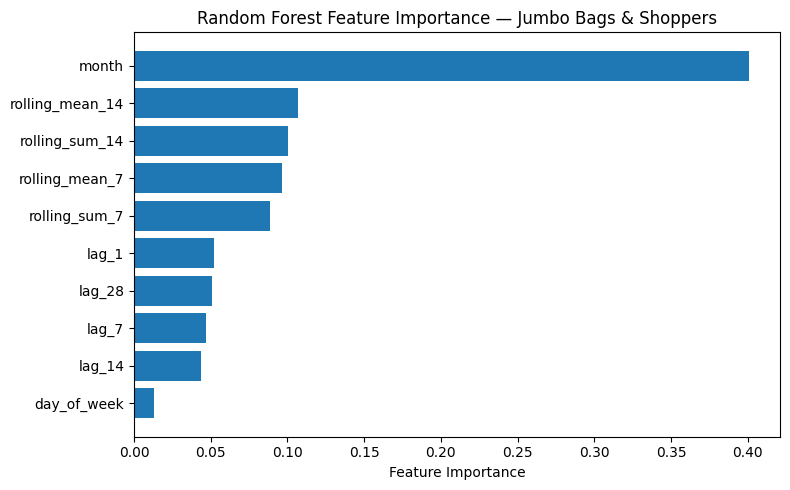

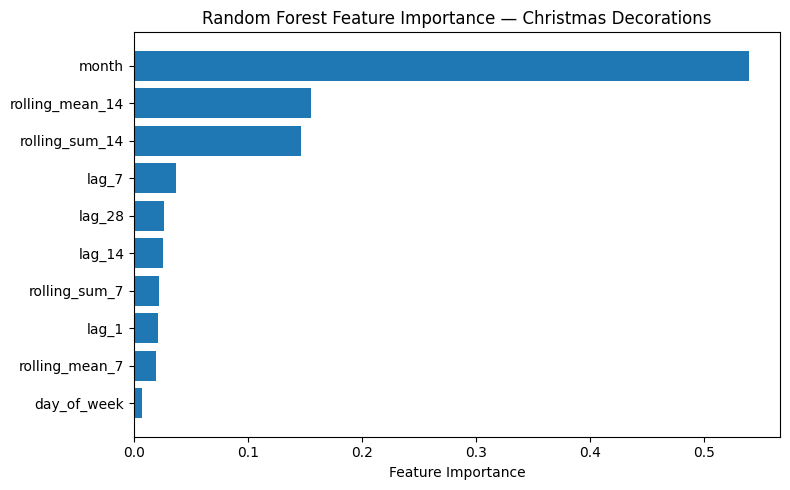

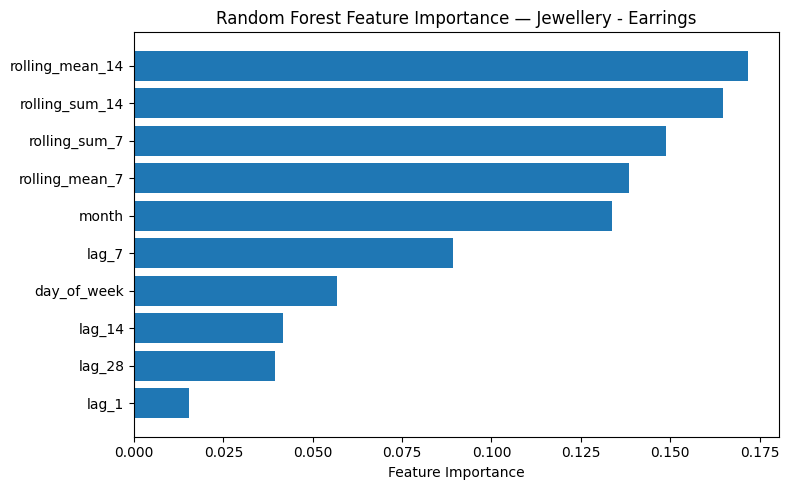

In [186]:
for category in selected_categories:
    category_importance = (
        feature_importance_df[feature_importance_df["Category"] == category]
        .sort_values("Importance")
    )
    
    plt.figure(figsize=(8, 5))
    plt.barh(
        category_importance["Feature"],
        category_importance["Importance"]
    )
    plt.title(f"Random Forest Feature Importance — {category}")
    plt.xlabel("Feature Importance")
    plt.tight_layout()
    plt.show()

### Interpretation

Random Forest feature importance confirms that feature usefulness depends on the category.

Rolling-window features are often important, which confirms that recent sales history is useful for forecasting.

The `month` feature is also important for some categories, especially categories with seasonal behavior.

Simple lag features are less stable than rolling features. This suggests that smoothed historical demand is more reliable than isolated past daily values.

This analysis confirms that some generated features may be weak or redundant. The next modeling iteration should test a reduced feature set and compare whether performance improves or remains stable.